In [208]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [209]:
df = pd.read_csv('marketing_campaign_data_messy.csv')
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


In [211]:
cat_cols = ['Channel','Active','Campaign_Tag']
num_cols = ['Impressions','Clicks','Spend','Conversions','Clicks*']

In [212]:
df.columns = df.columns.str.strip().str.replace(' ','_')

In [213]:
df.columns

Index(['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active', 'Clicks',
       'Campaign_Tag'],
      dtype='object')

In [214]:
# df['Start_Date'].isnull().sum()

In [215]:
# df['Start_Date'] = pd.to_datetime(df['Start_Date'],errors='coerce')

In [216]:
# df['Start_Date'].isnull().sum() 

In [217]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [218]:
df['Spend'] = df['Spend'].replace(r'[$-]',"",regex=True)

In [219]:
df['Spend'].dtype

dtype('O')

In [220]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [221]:
df['Spend'] = pd.to_numeric(df['Spend'])

In [222]:
df['Spend'].dtype

dtype('float64')

In [223]:
for col in cat_cols: 
    print(f"{col:<20}: {df[col].unique()}")

Channel             : ['TikTok' 'Facebook' 'Email' 'Instagram' 'Google Ads' 'E-mail' nan 'Gogle'
 'Tik_Tok' 'Facebok' 'Insta_gram']
Active              : ['Y' '0' 'No' 'True' 'Yes' '1' 'False']
Campaign_Tag        : ['TI' 'FA' 'EM' 'IN' 'GO' 'E-' 'INVALID' 'XX']


In [224]:
''' 
channel : tiktok , facebook , email , instagram , google_ads , nan
'''

' \nchannel : tiktok , facebook , email , instagram , google_ads , nan\n'

In [225]:
df[['Channel','Campaign_Tag']].sample(10)

,Channel,Campaign_Tag
1833,TikTok,TI
779,Insta_gram,IN
781,TikTok,TI
156,TikTok,TI
1559,Google Ads,GO
1124,Instagram,IN
559,TikTok,TI
1030,TikTok,TI
1253,Facebook,FA
1467,Facebook,FA


In [226]:
chnl = {
    'Tik_Tok':'TikTok', 
    'Facebok':'Facebook', 
    'E-mail':'Email', 
    'Insta_gram':'Instagram',
    'Gogle':'Google Ads', 
    'N/A':np.nan
}
df['Channel'] = df['Channel'].replace(chnl)

In [227]:
df['Channel'].unique() 

array(['TikTok', 'Facebook', 'Email', 'Instagram', 'Google Ads', nan],
      dtype=object)

In [228]:
actv = {
    'Y':"Yes", 
    '0':'No', 
    'True':'Yes', 
    '1':'Yes', 
    'False': 'No'
}
df['Active'] = df['Active'].replace(actv)
df['Active'].unique() 

array(['Yes', 'No'], dtype=object)

In [229]:
df.sample(10)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
855,CMP-00856,Q4_Summer_CMP-00856,2023-02-12 00:00:00,2023-02-14,Instagram,82317,2167,3341.47,234.0,Yes,NaN,IN
1397,CMP-01398,Q2_Winter_CMP-01398,2023-11-28 00:00:00,2023-12-24,Facebook,93201,4285,5702.20,NaN,Yes,NaN,FA
349,CMP-00350,Q2_Launch_CMP-00350,2023-05-09 00:00:00,2023-05-22,Facebook,75543,824,1166.91,138.0,Yes,NaN,FA
1519,CMP-01520,Q2_Launch_CMP-01520,2023-04-03 00:00:00,2023-04-22,Instagram,88833,2261,2838.76,285.0,Yes,NaN,IN
59,CMP-00060,Q2_BlackFriday_CMP-00060,2023-09-22 00:00:00,2023-10-12,Email,70479,1823,2634.34,112.0,Yes,NaN,EM
1547,CMP-01548,Q3_Winter_CMP-01548,2023-08-07 00:00:00,2023-08-27,Facebook,53375,2431,4617.53,295.0,No,NaN,FA
1657,CMP-01658,Q4_BlackFriday_CMP-01658,2023-12-06 00:00:00,2023-12-14,Facebook,19297,610,1089.12,NaN,No,NaN,FA
1740,CMP-01741,Q3_BlackFriday_CMP-01741,2023-07-04 00:00:00,2023-07-18,NaN,55302,1799,1009.96,339.0,Yes,NaN,XX
447,CMP-00448,Q1_Launch_CMP-00448,2023-09-27,2023-10-24,NaN,73615,3512,2313.63,NaN,Yes,NaN,XX
630,CMP-00631,Q4_Summer_CMP-00631,2023-06-24 00:00:00,2023-07-06,Google Ads,98203,2931,2405.02,205.0,Yes,NaN,GO


In [230]:
df = df.loc[:,~df.columns.duplicated()]

In [231]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,102.82,20.0,Yes,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,No,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,Yes,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,FA


In [232]:
impossible_mask = df['Clicks'] > df['Impressions']

df.loc[impossible_mask , ['Campaign_ID','Clicks','Impressions']]

,Campaign_ID,Clicks,Impressions


In [233]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'],errors='coerce')
df['End_Date'] = pd.to_datetime(df['End_Date'],errors='coerce')

In [234]:
impossible_time_mask = df['Start_Date'] > df['End_Date']

df.loc[impossible_time_mask , 'End_Date']  = df.loc[impossible_time_mask,'Start_Date'] + pd.Timedelta(days=30)

<Axes: ylabel='Spend'>

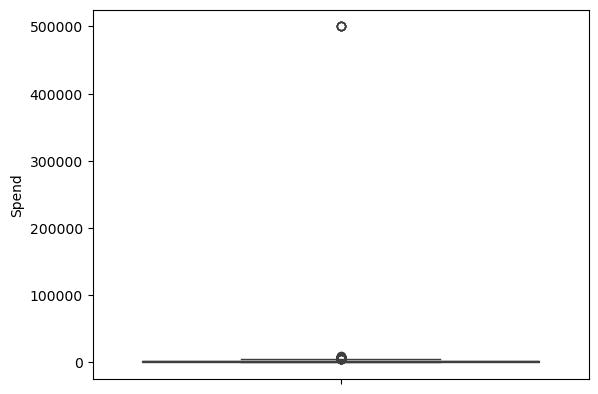

In [235]:
sns.boxplot(df['Spend'])

In [236]:
def outlier_remover(x): 
    q1 = df[x].quantile(0.25)
    q3 = df[x].quantile(0.75)

    iqr = q3 - q1 

    lower = q1 - iqr*1.5
    upper = q3 + iqr*1.5

    df.loc[ ( (df[x]<lower) | (df[x]>upper) ) ,x] = np.nan

<Axes: ylabel='Spend'>

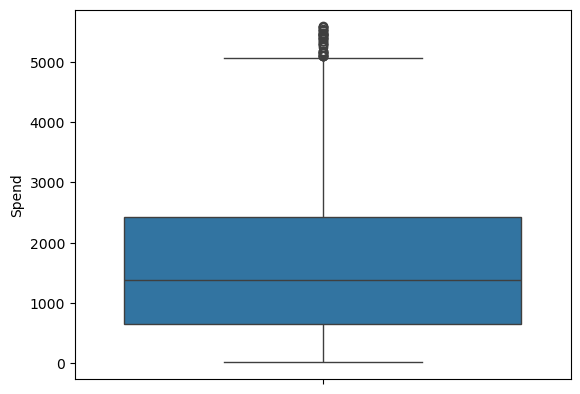

In [237]:
outlier_remover('Spend')
sns.boxplot(df['Spend'])

In [238]:
df['Spend'].isnull().sum() 

np.int64(76)

<Axes: ylabel='Conversions'>

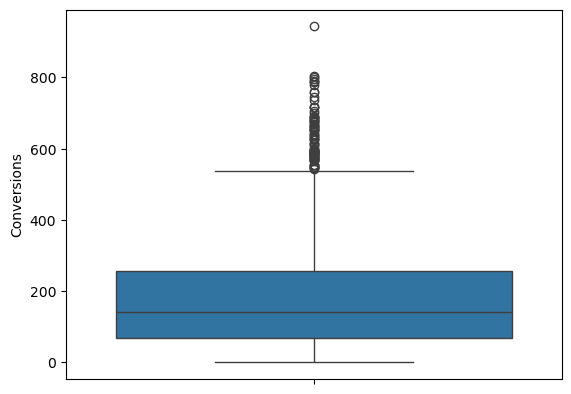

In [239]:
sns.boxplot(df['Conversions'])

In [240]:
outlier_remover('Conversions')

In [241]:
df.isnull().sum() 

Campaign_ID        0
Campaign_Name      0
Start_Date       333
End_Date           0
Channel          101
Impressions        0
Clicks             0
Spend             76
Conversions      288
Active             0
Campaign_Tag       0
dtype: int64

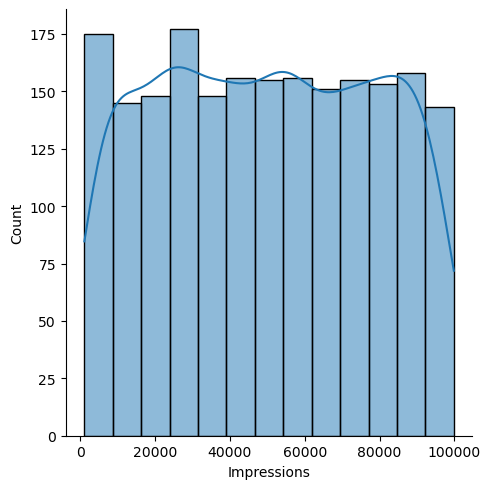

In [242]:
sns.displot(df['Impressions'],kde=True) #med = spend conversions

In [243]:
df['Spend'] = df['Spend'].fillna(df['Spend'].median())
df['Conversions'] = df['Conversions'].fillna(df['Conversions'].median())

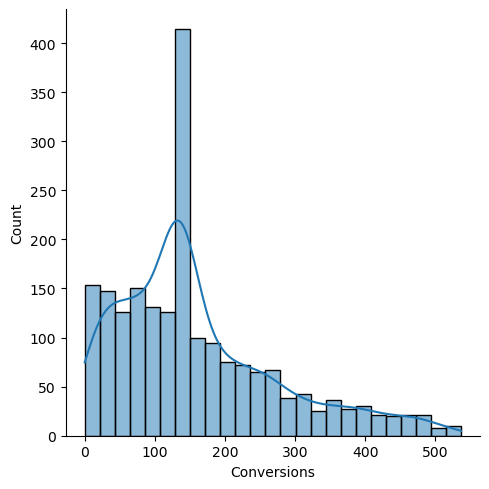

In [244]:
sns.displot(df['Conversions'],kde=True)

In [245]:
df.isnull().sum() 

Campaign_ID        0
Campaign_Name      0
Start_Date       333
End_Date           0
Channel          101
Impressions        0
Clicks             0
Spend              0
Conversions        0
Active             0
Campaign_Tag       0
dtype: int64

In [246]:
df['Channel'] = df['Channel'].fillna('Unknown')

In [247]:
campaign_map = {
    'TikTok':'TT', 'Facebook':'FB', 'Email':'EM', 'Instagram':'IG', 'Google Ads':'GG', 'Unknown':'XX'
}

In [248]:
df['Campaign_Tag'] = df['Channel'].map(campaign_map)

In [249]:
df.shape

(2020, 11)

In [250]:
df = df.drop_duplicates() 
df = df.reset_index(drop=True)

In [251]:
df.shape

(2000, 11)

In [252]:
df.columns

Index(['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active',
       'Campaign_Tag'],
      dtype='object')

In [253]:
df.to_csv('marketing_cleaned.csv')

In [254]:
df['duration'] = (df['End_Date'] - df['Start_Date']).dt.days

In [255]:
df.sample(10)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag,duration
740,CMP-00741,Q3_BlackFriday_CMP-00741,NaT,2023-10-15,Instagram,22447,713,1387.31,140.0,No,IG,NaN
1721,CMP-01722,Q2_Launch_CMP-01722,2023-10-11,2023-10-31,TikTok,68675,2350,3741.24,275.0,No,TT,20.0
1406,CMP-01407,Q1_Summer_CMP-01407,NaT,2024-01-04,Facebook,2622,51,79.48,7.0,Yes,FB,NaN
1045,CMP-01046,Q3_BlackFriday_CMP-01046,2023-07-16,2023-08-09,Email,43533,1138,2028.15,172.0,Yes,EM,24.0
898,CMP-00899,Q3_Winter_CMP-00899,NaT,2023-01-07,Email,25071,1077,659.08,208.0,Yes,EM,NaN
1565,CMP-01566,Q2_Winter_CMP-01566,NaT,2023-11-20,TikTok,16317,701,442.06,114.0,No,TT,NaN
1372,CMP-01373,Q4_Launch_CMP-01373,2023-12-21,2024-01-14,Google Ads,49285,752,910.68,40.0,No,GG,24.0
1800,CMP-01801,Q1_Summer_CMP-01801,2023-08-15,2023-08-31,Email,78475,1830,1519.78,138.0,Yes,EM,16.0
1557,CMP-01558,Q1_BlackFriday_CMP-01558,2023-06-23,2023-07-01,Email,24510,1107,1239.46,135.0,No,EM,8.0
1099,CMP-01100,Q3_Launch_CMP-01100,NaT,2023-03-21,TikTok,17984,449,258.83,75.0,Yes,TT,NaN


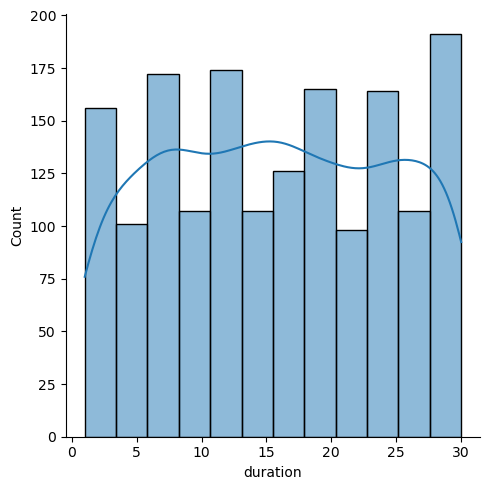

In [256]:
sns.displot(df['duration'],kde=True)

In [257]:
df['duration'] = df['duration'].fillna(df['duration'].mean())
# df['duration'].isnull().sum() 

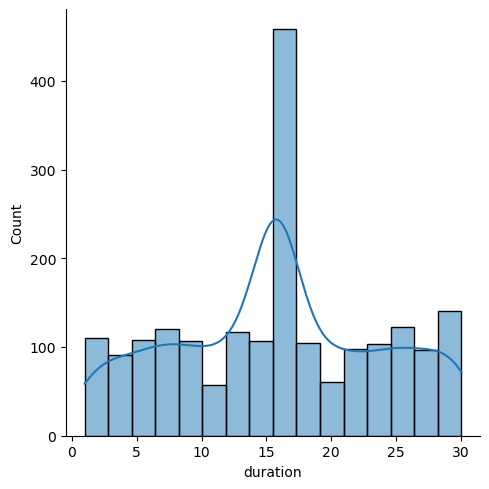

In [258]:
sns.displot(df['duration'],kde=True)

In [259]:
df = df.drop(['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date','Campaign_Tag','Conversions','Impressions'],axis=1)

In [260]:
df.head()

,Channel,Clicks,Spend,Active,duration
0,TikTok,197,102.82,Yes,19.000000
1,Facebook,30,24.33,No,6.000000
2,Email,843,1323.39,No,7.000000
3,TikTok,2019,2180.38,Yes,15.758393
4,Facebook,169,252.44,Yes,1.000000


In [261]:
active = {'Yes':1,'No':0}

In [262]:
df['Active'] = df['Active'].replace(active)

C:\Users\susha\AppData\Local\Temp\ipykernel_15264\1571786764.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Active'] = df['Active'].replace(active)


In [263]:
df.head()

,Channel,Clicks,Spend,Active,duration
0,TikTok,197,102.82,1,19.000000
1,Facebook,30,24.33,0,6.000000
2,Email,843,1323.39,0,7.000000
3,TikTok,2019,2180.38,1,15.758393
4,Facebook,169,252.44,1,1.000000


<Axes: >

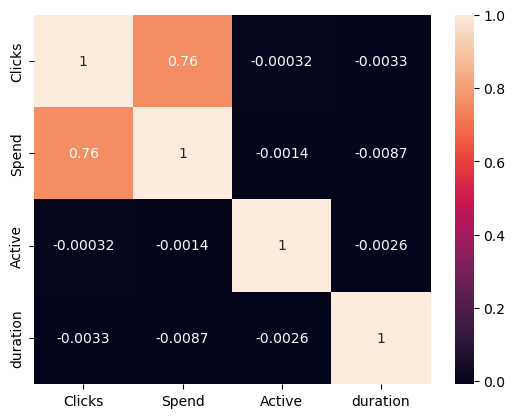

In [264]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [265]:
df = pd.get_dummies(df,columns=['Channel'],drop_first=True,dtype=float)

In [266]:
df.head()

,Clicks,Spend,Active,duration,Channel_Facebook,Channel_Google Ads,Channel_Instagram,Channel_TikTok,Channel_Unknown
0,197,102.82,1,19.000000,0.0,0.0,0.0,1.0,0.0
1,30,24.33,0,6.000000,1.0,0.0,0.0,0.0,0.0
2,843,1323.39,0,7.000000,0.0,0.0,0.0,0.0,0.0
3,2019,2180.38,1,15.758393,0.0,0.0,0.0,1.0,0.0
4,169,252.44,1,1.000000,1.0,0.0,0.0,0.0,0.0


In [267]:
# sns.heatmap(df.corr(),annot=True)

In [268]:
y = df['Active']
x = df.drop('Active',axis=1)

In [269]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [270]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [271]:
x.columns

Index(['Clicks', 'Spend', 'duration', 'Channel_Facebook', 'Channel_Google Ads',
       'Channel_Instagram', 'Channel_TikTok', 'Channel_Unknown'],
      dtype='object')

In [272]:
x_train.loc[:,[ 'Clicks', 'Spend', 'duration']] = scaler.fit_transform(x_train.loc[:,['Clicks', 'Spend', 'duration']])

C:\Users\susha\AppData\Local\Temp\ipykernel_15264\1461860982.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.13883675 -1.07313553 -1.35510325 ... -1.2821019  -0.54661327
 -0.86964426]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:,[ 'Clicks', 'Spend', 'duration']] = scaler.fit_transform(x_train.loc[:,['Clicks', 'Spend', 'duration']])


In [273]:
x_test.loc[:,['Clicks', 'Spend', 'duration']] = scaler.transform(x_test.loc[:,['Clicks', 'Spend', 'duration']])

C:\Users\susha\AppData\Local\Temp\ipykernel_15264\3753057582.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.29578966e+00 -1.11511131e+00 -1.23191347e+00  8.48484295e-02
 -6.50640200e-01  8.36762363e-01 -2.23582286e-01  1.04011285e-01
 -3.82360228e-01 -1.72481339e-01 -1.23205426e-01 -1.37033968e-02
 -1.16347470e+00  1.71734118e+00 -9.03407384e-01  1.06580411e+00
 -4.79999538e-01  9.46264392e-01  2.71837223e+00  6.93356420e-02
 -3.22134112e-01 -7.84920974e-02 -3.88747847e-01  3.54953435e-01
  1.04025363e+00 -2.44570175e-01 -5.17412731e-01  6.01333000e-01
  1.86137806e-01 -8.61431606e-01 -9.61808466e-01 -1.20453796e+00
 -9.30782891e-01 -1.19906286e+00  2.79214531e-01 -8.48656369e-01
 -1.31586503e+00 -1.23008844e+00  2.03033448e+00 -8.83332012e-01
 -7.78392567e-01 -5.75042085e-02 -4.32548658e-01 -1.03024723e+00
 -9.19832688e-01  3.96016696e-01 -4.85474639e-01  1.20633171e+00
  1.25925769e+00 -9.94799863e-02 -1

In [274]:
x_test.isnull().sum()

Clicks                0
Spend                 0
duration              0
Channel_Facebook      0
Channel_Google Ads    0
Channel_Instagram     0
Channel_TikTok        0
Channel_Unknown       0
dtype: int64

In [275]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(max_iter=1000)

In [276]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [277]:
y_pred = lg.predict(x_test)

In [278]:
from sklearn.metrics import roc_auc_score , confusion_matrix , accuracy_score , classification_report
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("ROC Accuracy : ",roc_auc_score(y_test,y_pred))
print("Confusion Matrix :\n",confusion_matrix(y_test,y_pred))
print("Classification Report : ",classification_report(y_test,y_pred))

Accuracy :  0.5916666666666667
ROC Accuracy :  0.5
Confusion Matrix :
 [[  0 245]
 [  0 355]]
Classification Report :                precision    recall  f1-score   support

           0       0.00      0.00      0.00       245
           1       0.59      1.00      0.74       355

    accuracy                           0.59       600
   macro avg       0.30      0.50      0.37       600
weighted avg       0.35      0.59      0.44       600



C:\Users\susha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\susha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\susha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [279]:
y_prob = lg.predict_proba(x_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.5256338028169013


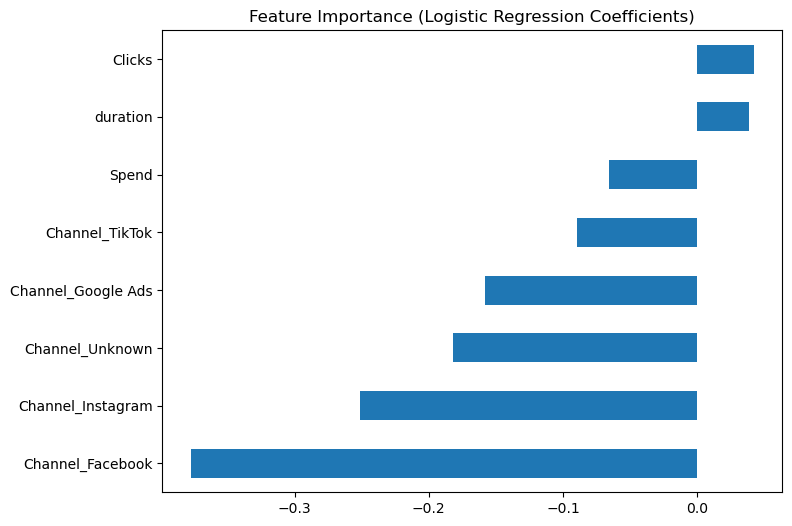

In [280]:
coef = pd.Series(lg.coef_[0], index=x.columns)
coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()